# 07 — LGBM Structural Swing-Trader (vtrain8 — Regime Filter)

## What changed vs vtrain7

| # | Problem (vtrain7) | Fix applied here |
|---|---|---|
| 1 | Feature importance dominated by `ret_1h`, `ret_2h`, `close_vs_ema_7` — short-term scalp noise that fee-kills any edge | **Banned noise features** hard-excluded from feature pool; model forced to learn structural indicators |
| 2 | Model generates strong short signals in a bull-market test window → systematic regime mismatch | **SMA-168 regime filter** baked into backtester: shorts muted if `close > sma_168`, longs muted if `close < sma_168` |
| 3 | Symmetric TBM barriers (±2.0×ATR) — equal PT/SL forces balanced label distribution with no edge asymmetry | **Asymmetric TBM**: PT = 2.5×ATR (wider), SL = 1.5×ATR (tighter). Lets winners run, cuts losers fast |
| 4 | 48-model × 6912-trading grid = 331k evaluations on same 61k-bar OOS → extreme selection bias | **Constrained trading grid** (≤36 combos), SL/TP baked-in (not searched). Model grid reduced to 32 configs |
| 5 | TBM vertical barrier at 24h — too tight for structural trades, forces neutral label at small moves | **48h horizon** — gives structural moves more time to develop before timing out to neutral |

## Architecture

```
Phase 0: Feature prep    -> Ban noise features; compute sma_168 from raw close
Phase 1: Asymmetric TBM  -> PT=2.5xATR, SL=1.5xATR, H=48h  (3 classes)
Phase 2: Combined grid
  For each MODEL_GRID config (32):
    Feature selection: RF importance + corr filter (no banned features)
    Purged K-Fold (K=5, embargo=168h) -> OOS probs (N, 3) [cached]
    For each TRADING_GRID combo (<=36):
      run_backtest_v8(p_up, p_down, sma168, ...) -> score  [regime filter active]
Phase 3: WFO on test set (best model config + best trading params)
Phase 4: Final evaluation + comparison
```

## Regime filter logic
- `close > sma_168` → **bull regime** → longs allowed, **shorts muted**
- `close < sma_168` → **bear regime** → shorts allowed, **longs muted**
- Derived from training data only (no future information — SMA-168 is backward-looking)

## Spot vs Futures execution (same as vtrain7)
- **Longs (Spot):** limit entry 0% fee / TP 0% fee / SL+time 0.05% taker / Funding 0.00%/h
- **Shorts (Futures):** limit entry 0% fee / TP 0% fee / SL+time 0.05% taker / Funding +0.00077%/h RECEIVED
- Entry pullback: fixed 0.2×ATR (limit order; ~50% fill rate expected)
- SL/TP hardcoded: SL=1.5×ATR, TP=2.5×ATR (not grid-searched)

In [1]:
SYMBOL    = 'BTCUSDT'
INTERVAL  = '1h'
TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

# Purged K-Fold
K                    = 5
EMBARGO              = 168
KFOLD_INTERNAL_VAL_H = 2500
EARLY_STOPPING_ROUNDS = 50

# Walk-Forward Optimization
WFO_STEP_H         = 720
WFO_INTERNAL_VAL_H = 2500
WFO_PATIENCE       = 50

# Asymmetric TBM labeling
# Class 1 = Long  (upper barrier close*(1+TBM_PT_MULT*atr) hit first)
# Class 0 = Short (lower barrier close*(1-TBM_SL_MULT*atr) hit first)
# Class 2 = Neutral (48h vertical barrier hit first)
TBM_PT_MULT = 2.5   # profit-taking barrier — wider, lets winners run
TBM_SL_MULT = 1.5   # stop-loss barrier    — tighter, cuts losers fast
TBM_HORIZON = 48    # extended to give structural moves time to develop

# Regime filter
REGIME_SMA_PERIOD = 168   # 1-week SMA — structural trend identifier

# Execution: Spot/Futures routing (same as vtrain7)
MAKER_FEE         = 0.0000     # 0%    - limit orders (entries + TP exits)
SPOT_TAKER_FEE    = 0.0005     # 0.05% - Spot taker (SL/time exits on longs)
FUTURES_TAKER_FEE = 0.0005     # 0.05% - Futures taker (SL/time exits on shorts)
BUFFER            = 0.0005     # 5bp penetration buffer for limit fill confirmation
SPOT_FUNDING_H    = 0.0        # Spot longs: zero funding
SHORT_FUNDING_H   = 0.0000077  # Futures shorts: +0.00077%/h RECEIVED per hour held

# Fixed execution params (not grid-searched)
ENTRY_ATR_MULT = 0.2    # limit pullback depth — conservative, ~50% fill rate
SL_ATR_MULT    = 1.5    # must match TBM_SL_MULT for label/execution consistency
TP_ATR_MULT    = 2.5    # must match TBM_PT_MULT
MIN_SL         = 0.010  # 1% absolute floor on stop loss

# Optimisation
OPTIMISE_METRIC = 'sharpe'
MIN_TRADES      = 20    # lower threshold — regime filter reduces trade count
TOP_N           = 20

# Banned noise features (short-term return features that cause fee-killing scalp behaviour)
BANNED_FEATURES = {
    'ret_1h', 'log_ret_1h',
    'ret_2h', 'log_ret_2h',
    'close_vs_ema_7',
}

# Model grid (2x2x2x2x2 = 32 configs)
RF_N_ESTIMATORS = 200

MODEL_GRID = {
    'top_n_features':    [25, 35],
    'corr_threshold':    [0.85, 0.90],
    'num_leaves':        [31, 63],
    'min_child_samples': [30, 50],
    'learning_rate':     [0.01, 0.02],
}

BASE_LGB_PARAMS = {
    'objective':        'multiclass',
    'num_class':        3,
    'metric':           'multi_logloss',
    'n_estimators':     1000,
    'max_depth':        -1,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'reg_alpha':        0.1,
    'reg_lambda':       1.0,
    'random_state':     42,
    'n_jobs':           -1,
    'verbose':          -1,
}

# Constrained trading grid: only confidence thresholds and holding periods
# SL/TP baked in as fixed params above — not searched
# Total: 3 x 3 x 2 x 1 x 1 = 18 combos (well under 36 max)
TRADING_GRID = {
    'long_threshold':  [0.45, 0.50, 0.55],
    'short_threshold': [0.45, 0.50, 0.55],
    'min_hold':        [8, 12],
    'max_hold':        [48],
    'cooldown':        [4],
}

In [2]:
import itertools
import json
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9,  'ytick.labelsize': 9,
    'legend.fontsize': 9,  'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT = '#F7931A'; BLUE = '#2962FF'; GREY = '#9E9E9E'
RED    = '#EF5350'; GREEN = '#26A69A'; PURPLE = '#7B1FA2'

REPO_ROOT = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists():
    REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
RAW_DIR      = REPO_ROOT / 'data' / 'raw'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists():
    MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR  = REPO_ROOT / 'figures' / 'grid_lgbm'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO_ROOT  : {REPO_ROOT}')
print(f'MODELS_DIR : {MODELS_DIR}')
print(f'vtrain8 -- Asymmetric TBM | Regime filter (SMA-{REGIME_SMA_PERIOD}) | Banned noise features')
print(f'TBM: PT={TBM_PT_MULT}xATR  SL={TBM_SL_MULT}xATR  H={TBM_HORIZON}h')
print(f'Banned features: {sorted(BANNED_FEATURES)}')
print(f'Spot longs: taker={SPOT_TAKER_FEE*100:.3f}%  funding=0%/h')
print(f'Futures shorts: taker={FUTURES_TAKER_FEE*100:.3f}%  funding received=+{SHORT_FUNDING_H*100:.5f}%/h')

REPO_ROOT  : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
MODELS_DIR : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models
vtrain8 -- Asymmetric TBM | Regime filter (SMA-168) | Banned noise features
TBM: PT=2.5xATR  SL=1.5xATR  H=48h
Banned features: ['close_vs_ema_7', 'log_ret_1h', 'log_ret_2h', 'ret_1h', 'ret_2h']
Spot longs: taker=0.050%  funding=0%/h
Futures shorts: taker=0.050%  funding received=+0.00077%/h


Dataset after joins: (74199, 202)
Index: 2017-11-22 -> 2026-05-16
Feature pool after banning noise: 192 features
Banned: ['close_vs_ema_7', 'log_ret_1h', 'log_ret_2h', 'ret_1h', 'ret_2h']

TrainVal:  60,951 bars | Short(0)=36,758 (60.3%) | Long(1)=21,740 (35.7%) | Neutral(2)=2,453 (4.0%)
Test    :  13,200 bars | Short(0)=7,918 (60.0%) | Long(1)=4,741 (35.9%) | Neutral(2)=541 (4.1%)

Test regime: 52.5% bull (above SMA-168), 47.5% bear
→ Regime filter will mute shorts for 52.5% of test bars


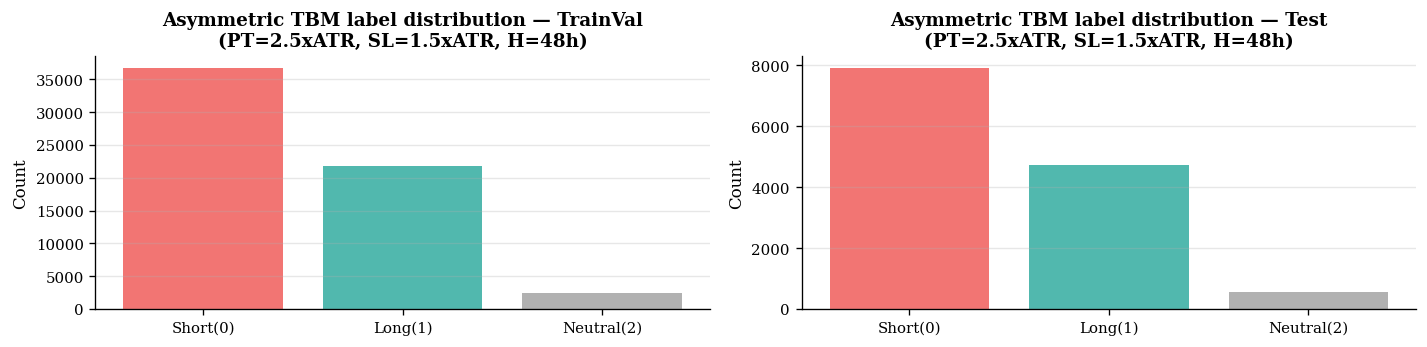

In [3]:
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

raw_df = pd.read_parquet(RAW_DIR / f'{SYMBOL}_{INTERVAL}.parquet')
raw_df.index = raw_df.index.tz_localize(None) if raw_df.index.tz else raw_df.index

# Join high/low from raw OHLCV (needed for intra-candle barrier checks)
feat_df = feat_df.join(raw_df[['high', 'low']], how='left')
feat_df = feat_df.dropna(subset=['high', 'low'])

# Compute SMA-168 regime indicator from raw close (backward-looking, no leakage)
feat_df['sma_168'] = feat_df['close'].rolling(REGIME_SMA_PERIOD, min_periods=REGIME_SMA_PERIOD).mean()
feat_df = feat_df.dropna(subset=['sma_168'])

print(f'Dataset after joins: {feat_df.shape}')
print(f'Index: {feat_df.index.min().date()} -> {feat_df.index.max().date()}')


def make_tbm_labels_asymmetric(close_arr, high_arr, low_arr, atr_arr,
                                pt_mult=2.5, sl_mult=1.5, horizon=48):
    """Asymmetric Triple Barrier Method.
    Class 1: upper PT barrier close*(1+pt_mult*atr) hit first -> Long
    Class 0: lower SL barrier close*(1-sl_mult*atr) hit first -> Short
    Class 2: time barrier hit first -> Neutral
    Last `horizon` rows labelled -1 (insufficient lookahead, dropped).
    Wider PT than SL lets winners run — matches backtester execution params.
    """
    N      = len(close_arr)
    labels = np.full(N, 2, dtype=np.int8)
    for i in range(N - horizon):
        c     = close_arr[i]
        atr   = atr_arr[i]
        upper = c * (1.0 + pt_mult * atr)
        lower = c * (1.0 - sl_mult * atr)
        for j in range(i + 1, i + horizon + 1):
            if high_arr[j] >= upper:
                labels[i] = 1; break
            elif low_arr[j] <= lower:
                labels[i] = 0; break
    labels[N - horizon:] = -1
    return labels


tbm = make_tbm_labels_asymmetric(
    feat_df['close'].values, feat_df['high'].values, feat_df['low'].values,
    feat_df['atr_14_pct'].values,
    pt_mult=TBM_PT_MULT, sl_mult=TBM_SL_MULT, horizon=TBM_HORIZON,
)
feat_df['tbm_label'] = tbm
feat_df = feat_df[feat_df['tbm_label'] >= 0].copy()

# Calendar split
train_df, val_df, test_df = calendar_split(feat_df, train_end=TRAIN_END, val_end=VAL_END)
trainval_df = pd.concat([train_df, val_df]).sort_index()

# Feature columns — exclude metadata, target, and banned noise features
_ALWAYS_EXCLUDE = {
    'open', 'high', 'low', 'close', 'volume', 'label', 'tbm_label',
    'return', 'log_return', 'target', 'future_return', 'sma_168',
}
feature_cols = [
    c for c in feat_df.columns
    if c not in _ALWAYS_EXCLUDE
    and c not in BANNED_FEATURES
    and not c.startswith('future_')
    and pd.api.types.is_numeric_dtype(feat_df[c])
]

def _arr(df, col): return df[col].values.astype(np.float64)

X_tv   = trainval_df[feature_cols].values.astype(np.float32)
y_tv   = trainval_df['tbm_label'].values.astype(int)
X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df['tbm_label'].values.astype(int)

tv_close  = _arr(trainval_df, 'close');  tv_high   = _arr(trainval_df, 'high')
tv_low    = _arr(trainval_df, 'low');    tv_atr    = _arr(trainval_df, 'atr_14_pct')
tv_sma168 = _arr(trainval_df, 'sma_168')
tv_index  = trainval_df.index

test_close  = _arr(test_df, 'close');    test_high   = _arr(test_df, 'high')
test_low    = _arr(test_df, 'low');      test_atr    = _arr(test_df, 'atr_14_pct')
test_sma168 = _arr(test_df, 'sma_168')
test_index  = test_df.index

print(f'Feature pool after banning noise: {len(feature_cols)} features')
print(f'Banned: {sorted(BANNED_FEATURES & set(feat_df.columns))}')
print()
for split, df in [('TrainVal', trainval_df), ('Test', test_df)]:
    vc = df['tbm_label'].value_counts().sort_index()
    n  = len(df)
    print(f'{split:8s}: {n:>7,} bars | '
          f'Short(0)={vc.get(0,0):,} ({vc.get(0,0)/n:.1%}) | '
          f'Long(1)={vc.get(1,0):,} ({vc.get(1,0)/n:.1%}) | '
          f'Neutral(2)={vc.get(2,0):,} ({vc.get(2,0)/n:.1%})')

# Regime distribution in test set
bull_pct = (test_df['close'] > test_df['sma_168']).mean()
print(f'\nTest regime: {bull_pct:.1%} bull (above SMA-168), {1-bull_pct:.1%} bear')
print('→ Regime filter will mute shorts for {:.1%} of test bars'.format(bull_pct))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, (lbl, df) in zip(axes, [('TrainVal', trainval_df), ('Test', test_df)]):
    vc = df['tbm_label'].value_counts().sort_index()
    ax.bar(['Short(0)', 'Long(1)', 'Neutral(2)'],
           [vc.get(0, 0), vc.get(1, 0), vc.get(2, 0)],
           color=[RED, GREEN, GREY], alpha=0.8)
    ax.set_title(f'Asymmetric TBM label distribution — {lbl}\n'
                 f'(PT={TBM_PT_MULT}xATR, SL={TBM_SL_MULT}xATR, H={TBM_HORIZON}h)',
                 fontweight='bold')
    ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'tbm_label_distribution_vtrain8.png'); plt.show()

In [4]:
def select_features(X_train, y_train, cols, top_n, corr_thresh, n_estimators=200):
    """RF importance + greedy correlation filter -> top_n features.
    Input feature pool already has noise features removed.
    """
    rf = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=8,
        min_samples_leaf=50, n_jobs=-1, random_state=42,
    )
    rf.fit(X_train, y_train)
    imp_df = (pd.DataFrame({'feature': cols, 'importance': rf.feature_importances_})
              .sort_values('importance', ascending=False).reset_index(drop=True))
    corr_mat = pd.DataFrame(X_train, columns=cols).corr().abs()
    kept = []
    for feat in imp_df['feature']:
        if not any(corr_mat.loc[feat, k] > corr_thresh for k in kept):
            kept.append(feat)
        if len(kept) >= top_n:
            break
    return kept[:top_n]


print('select_features() defined')
print(f'Feature pool (noise-free): {len(feature_cols)} features')
print(f'Model grid will select top 25 or 35 from this pool')

select_features() defined
Feature pool (noise-free): 192 features
Model grid will select top 25 or 35 from this pool


In [5]:
def run_backtest_v8(
        p_up, p_down, close_arr, high_arr, low_arr, atr_arr, sma168_arr, params,
        sl_atr=SL_ATR_MULT, tp_atr=TP_ATR_MULT,
        entry_atr=ENTRY_ATR_MULT, min_sl=MIN_SL,
        spot_taker=SPOT_TAKER_FEE, fut_taker=FUTURES_TAKER_FEE,
        maker_fee=MAKER_FEE, buf=BUFFER,
        spot_fund=SPOT_FUNDING_H, short_fund=SHORT_FUNDING_H):
    """Structural swing-trader backtester with SMA-168 regime filter.

    Key additions vs v7:
    - SMA-168 regime filter: shorts muted if close > sma_168; longs muted if close < sma_168
    - SL/TP hardcoded (not grid-searched): SL=1.5xATR, TP=2.5xATR
    - Entry pullback fixed at 0.2xATR
    - Spot/Futures routing same as v7
    - Pessimistic both-hit: SL wins when wick penetrates both barriers in same bar
    """
    lt         = params['long_threshold']
    st         = params['short_threshold']
    exit_long  = 1.0 - lt
    exit_short = 1.0 - st
    min_hold   = int(params['min_hold'])
    max_hold   = int(params['max_hold'])
    cd_n       = int(params['cooldown'])

    cash = 1.0; units = 0.0; entry_cash = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; dynamic_sl = 0.0; dynamic_tp = 0.0
    hold_count = 0; cooldown = 0; entry_bar = -1
    pending = None

    equity_curve = [1.0]
    trade_log    = []
    n_signals = 0; n_fills = 0; n_expires = 0
    n_longs_muted = 0; n_shorts_muted = 0

    N = len(close_arr)
    for i in range(N):
        px    = close_arr[i]; hi   = high_arr[i]; lo  = low_arr[i]
        pup   = p_up[i];      pdn  = p_down[i];   atr = atr_arr[i]
        sma16 = sma168_arr[i]
        if cooldown > 0:
            cooldown -= 1

        # Regime filter: determine which directions are allowed this bar
        bull_regime = px > sma16   # above SMA-168 = bullish structural trend
        long_allowed  = bull_regime   # only allow longs in bull regime
        short_allowed = not bull_regime  # only allow shorts in bear regime

        # 1. Fill / expire pending limit order (TIF = 1 bar)
        if pending is not None:
            lp  = pending['limit_px']
            dir = pending['direction']
            if dir == 'long':
                if lo < lp * (1.0 - buf):
                    units = cash * (1.0 - maker_fee) / lp
                    cash = 0.0; in_pos = True; direction = 'long'
                    entry_px = lp; entry_bar = i; hold_count = 0
                    dynamic_sl = pending['sl']; dynamic_tp = pending['tp']
                    n_fills += 1
                else:
                    n_expires += 1
            else:  # short
                if hi > lp * (1.0 + buf):
                    entry_cash = cash * (1.0 - maker_fee)
                    cash = 0.0; units = entry_cash / lp
                    in_pos = True; direction = 'short'
                    entry_px = lp; entry_bar = i; hold_count = 0
                    dynamic_sl = pending['sl']; dynamic_tp = pending['tp']
                    n_fills += 1
                else:
                    n_expires += 1
            pending = None

        # 2. Manage open position
        if in_pos and i > entry_bar:
            hold_count += 1
            if direction == 'long':
                units *= (1.0 - spot_fund)
            else:
                entry_cash *= (1.0 + short_fund)

            reason = None; exit_px = px; pnl = 0.0

            if direction == 'long':
                sl_price = entry_px * (1.0 - dynamic_sl)
                tp_price = entry_px * (1.0 + dynamic_tp)
                tp_check = tp_price * (1.0 + buf)
                sl_hit   = lo <= sl_price
                tp_hit   = hi > tp_check
                if sl_hit and tp_hit:             # pessimistic: SL wins
                    reason = 'sl'; exit_px = sl_price
                    pnl  = (exit_px - entry_px) / entry_px
                    cash = units * exit_px * (1.0 - spot_taker); units = 0.0
                elif sl_hit:
                    reason = 'sl'; exit_px = sl_price
                    pnl  = (exit_px - entry_px) / entry_px
                    cash = units * exit_px * (1.0 - spot_taker); units = 0.0
                elif tp_hit:
                    reason = 'tp'; exit_px = tp_price
                    pnl  = (exit_px - entry_px) / entry_px
                    cash = units * exit_px * (1.0 - maker_fee); units = 0.0
                elif hold_count >= max_hold:
                    reason = 'max_hold'; exit_px = px
                    pnl  = (px - entry_px) / entry_px
                    cash = units * px * (1.0 - spot_taker); units = 0.0
                elif hold_count >= min_hold and pup < exit_long:
                    reason = 'conf'; exit_px = px
                    pnl  = (px - entry_px) / entry_px
                    cash = units * px * (1.0 - spot_taker); units = 0.0
            else:  # short
                sl_price = entry_px * (1.0 + dynamic_sl)
                tp_price = entry_px * (1.0 - dynamic_tp)
                tp_check = tp_price * (1.0 - buf)
                sl_hit   = hi >= sl_price
                tp_hit   = lo < tp_check
                if sl_hit and tp_hit:             # pessimistic: SL wins
                    reason = 'sl'; exit_px = sl_price
                    gross = (entry_px - exit_px) / entry_px; pnl = gross
                    cash  = entry_cash * (1.0 + gross) * (1.0 - fut_taker)
                elif sl_hit:
                    reason = 'sl'; exit_px = sl_price
                    gross = (entry_px - exit_px) / entry_px; pnl = gross
                    cash  = entry_cash * (1.0 + gross) * (1.0 - fut_taker)
                elif tp_hit:
                    reason = 'tp'; exit_px = tp_price
                    gross = (entry_px - exit_px) / entry_px; pnl = gross
                    cash  = entry_cash * (1.0 + gross) * (1.0 - maker_fee)
                elif hold_count >= max_hold:
                    reason = 'max_hold'; exit_px = px
                    gross = (entry_px - px) / entry_px; pnl = gross
                    cash  = entry_cash * (1.0 + gross) * (1.0 - fut_taker)
                elif hold_count >= min_hold and pdn < exit_short:
                    reason = 'conf'; exit_px = px
                    gross = (entry_px - px) / entry_px; pnl = gross
                    cash  = entry_cash * (1.0 + gross) * (1.0 - fut_taker)

            if reason:
                trade_log.append({'direction': direction, 'pnl_pct': pnl,
                                   'hold_h': hold_count, 'reason': reason})
                in_pos = False; direction = None; hold_count = 0; cooldown = cd_n

        # 3. Place new pending limit order if flat — regime filter applied here
        if not in_pos and pending is None and cooldown == 0:
            sl_v = max(sl_atr * atr, min_sl)
            tp_v = tp_atr * atr
            if pup >= lt and long_allowed:
                limit_px = px * (1.0 - entry_atr * atr)
                pending  = {'direction': 'long',  'limit_px': limit_px, 'sl': sl_v, 'tp': tp_v}
                n_signals += 1
            elif pdn >= st and short_allowed:
                limit_px = px * (1.0 + entry_atr * atr)
                pending  = {'direction': 'short', 'limit_px': limit_px, 'sl': sl_v, 'tp': tp_v}
                n_signals += 1
            elif pup >= lt and not long_allowed:
                n_longs_muted += 1
            elif pdn >= st and not short_allowed:
                n_shorts_muted += 1

        # Equity mark-to-market
        if   in_pos and direction == 'long':
            equity_curve.append(units * px)
        elif in_pos and direction == 'short':
            equity_curve.append(entry_cash * (1.0 + (entry_px - px) / entry_px))
        else:
            equity_curve.append(cash)

    # Force-close at end
    if in_pos:
        px = close_arr[-1]
        if direction == 'long':
            gross = (px - entry_px) / entry_px
            cash  = units * px * (1.0 - spot_taker)
        else:
            gross = (entry_px - px) / entry_px
            cash  = entry_cash * (1.0 + gross) * (1.0 - fut_taker)
        trade_log.append({'direction': direction, 'pnl_pct': gross,
                           'hold_h': hold_count, 'reason': 'eod'})
        equity_curve[-1] = cash

    tdf = pd.DataFrame(trade_log)
    tdf.attrs['n_signals']      = n_signals
    tdf.attrs['n_fills']        = n_fills
    tdf.attrs['n_expires']      = n_expires
    tdf.attrs['n_longs_muted']  = n_longs_muted
    tdf.attrs['n_shorts_muted'] = n_shorts_muted
    return np.array(equity_curve[1:]), tdf


def score_equity(equity_arr, trades_df, metric):
    if trades_df.empty: return -np.inf
    eq  = equity_arr
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    ann = 24 * 365
    if metric == 'sharpe':
        return float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(ann))
    if metric == 'total_return':
        return float(eq[-1] - 1)
    if metric == 'calmar':
        ar  = float((eq[-1] ** (ann / len(eq))) - 1)
        pk  = np.maximum.accumulate(eq)
        mdd = float(((eq - pk) / (pk + 1e-12)).min())
        return ar / (abs(mdd) + 1e-6)
    if metric == 'win_rate':
        return float((trades_df['pnl_pct'] > 0).mean())
    if metric == 'profit_factor':
        g = trades_df[trades_df['pnl_pct'] > 0]['pnl_pct'].sum()
        l = trades_df[trades_df['pnl_pct'] < 0]['pnl_pct'].abs().sum()
        return float(g / (l + 1e-6))
    return -np.inf


print('run_backtest_v8() defined')
print(f'  Fixed SL={SL_ATR_MULT}xATR  TP={TP_ATR_MULT}xATR  entry={ENTRY_ATR_MULT}xATR')
print(f'  Regime filter: SMA-{REGIME_SMA_PERIOD}')
print(f'    > SMA-{REGIME_SMA_PERIOD}: longs allowed, shorts MUTED')
print(f'    < SMA-{REGIME_SMA_PERIOD}: shorts allowed, longs MUTED')

run_backtest_v8() defined
  Fixed SL=1.5xATR  TP=2.5xATR  entry=0.2xATR
  Regime filter: SMA-168
    > SMA-168: longs allowed, shorts MUTED
    < SMA-168: shorts allowed, longs MUTED


In [6]:
def purged_kfold_oos_probs(X, y, lgb_params,
                            k=K, embargo=EMBARGO,
                            internal_val_h=KFOLD_INTERNAL_VAL_H,
                            es_rounds=EARLY_STOPPING_ROUNDS):
    """Purged K-Fold cross-validation for multiclass LGBM.
    Internal val set carved from bars immediately before each fold's embargo zone
    (vtrain4+ temporal fix — avoids training-on-future-val-data leakage).
    Returns OOS probability array shape (N, num_class); NaN where embargoed.
    """
    N         = len(X)
    fold_size = N // k
    num_class = lgb_params.get('num_class', 3)
    oos_probs = np.full((N, num_class), np.nan)

    for fold_k in range(k):
        fold_start = fold_k * fold_size
        fold_end   = (fold_k + 1) * fold_size if fold_k < k - 1 else N
        emb_start  = max(0, fold_start - embargo)
        emb_end    = min(N, fold_end   + embargo)

        # Internal val: 2500 bars before the embargo zone (temporal fix)
        if emb_start >= 200:
            n_int     = min(internal_val_h, emb_start)
            int_end   = emb_start
            int_start = emb_start - n_int
        else:
            n_int     = min(internal_val_h, N - emb_end)
            int_start = emb_end
            int_end   = min(N, emb_end + n_int)
            n_int     = int_end - int_start

        mask = np.ones(N, dtype=bool)
        mask[emb_start:emb_end] = False
        mask[int_start:int_end] = False

        ds_tr = lgb.Dataset(X[mask],              label=y[mask])
        ds_vl = lgb.Dataset(X[int_start:int_end], label=y[int_start:int_end],
                             reference=ds_tr)
        model = lgb.train(
            lgb_params, ds_tr,
            valid_sets=[ds_tr, ds_vl], valid_names=['train', 'val'],
            callbacks=[
                lgb.early_stopping(stopping_rounds=es_rounds, verbose=False),
                lgb.log_evaluation(period=0),
            ],
        )
        oos_probs[fold_start:fold_end] = model.predict(X[fold_start:fold_end])
        del model

    return oos_probs  # shape (N, 3)


print('purged_kfold_oos_probs() defined  (K=5, embargo=168h, internal_val=2500)')

purged_kfold_oos_probs() defined  (K=5, embargo=168h, internal_val=2500)


In [7]:
model_keys   = list(MODEL_GRID.keys())
model_combos = list(itertools.product(*[MODEL_GRID[k] for k in model_keys]))

trading_keys   = list(TRADING_GRID.keys())
trading_combos = list(itertools.product(*[TRADING_GRID[k] for k in trading_keys]))
valid_trading  = [dict(zip(trading_keys, v)) for v in trading_combos]

total = len(model_combos) * len(valid_trading)
print(f'Model configs    : {len(model_combos):,}   (2^5 = 32)')
print(f'Trading combos   : {len(valid_trading):,}   (constrained grid)')
print(f'Total evaluations: {total:,}  (vs 331k in vtrain7)')
print(f'Fixed params     : entry={ENTRY_ATR_MULT}xATR  SL={SL_ATR_MULT}xATR  TP={TP_ATR_MULT}xATR  min_sl={MIN_SL:.1%}')

all_results    = []
oos_prob_cache = {}   # model_id -> dict with arrays + metadata
t0 = time.perf_counter()

for mid, m_vals in enumerate(tqdm(model_combos, desc='Model configs')):
    cfg = dict(zip(model_keys, m_vals))

    # Feature selection on full trainval (once per model config)
    sel_feats = select_features(
        X_tv, y_tv, feature_cols,
        top_n=cfg['top_n_features'],
        corr_thresh=cfg['corr_threshold'],
        n_estimators=RF_N_ESTIMATORS,
    )
    fi       = [feature_cols.index(f) for f in sel_feats]
    X_tv_sel = X_tv[:, fi]

    lgb_params = {
        **BASE_LGB_PARAMS,
        'num_leaves':        cfg['num_leaves'],
        'min_child_samples': cfg['min_child_samples'],
        'learning_rate':     cfg['learning_rate'],
    }

    # Purged K-Fold -> OOS probs shape (N, 3)
    oos_probs = purged_kfold_oos_probs(X_tv_sel, y_tv, lgb_params)

    valid_idx = np.isfinite(oos_probs[:, 0])
    p_up  = oos_probs[valid_idx, 1].astype(np.float64)
    p_dn  = oos_probs[valid_idx, 0].astype(np.float64)
    c_arr = tv_close[valid_idx];    h_arr    = tv_high[valid_idx]
    l_arr = tv_low[valid_idx];      a_arr    = tv_atr[valid_idx]
    s_arr = tv_sma168[valid_idx]
    oos_y = y_tv[valid_idx]

    auc_long  = roc_auc_score((oos_y == 1).astype(int), p_up)
    auc_short = roc_auc_score((oos_y == 0).astype(int), p_dn)
    tqdm.write(
        f'  [{mid:02d}] top_n={cfg["top_n_features"]} lr={cfg["learning_rate"]:.2f} '
        f'leaves={cfg["num_leaves"]} mc={cfg["min_child_samples"]} '
        f'corr={cfg["corr_threshold"]} | '
        f'AUC_long={auc_long:.4f}  AUC_short={auc_short:.4f}'
    )

    oos_prob_cache[mid] = {
        'p_up': p_up, 'p_dn': p_dn,
        'c': c_arr, 'h': h_arr, 'l': l_arr, 'a': a_arr, 's168': s_arr,
        'oos_idx': tv_index[valid_idx],
        'sel_feats': sel_feats, 'fi': fi,
        'config': cfg, 'auc_long': auc_long, 'auc_short': auc_short,
    }

    # Inner loop: trading grid (constrained)
    for tp in valid_trading:
        eq, tdf = run_backtest_v8(p_up, p_dn, c_arr, h_arr, l_arr, a_arr, s_arr, tp)
        if len(tdf) < MIN_TRADES:
            continue
        s   = score_equity(eq, tdf, OPTIMISE_METRIC)
        ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
        pk  = np.maximum.accumulate(eq)
        fr  = tdf.attrs.get('n_fills', 0) / max(tdf.attrs.get('n_signals', 1), 1)
        all_results.append({
            'model_id':       mid,
            **tp,
            'score':          s,
            'total_return':   float(eq[-1] - 1),
            'sharpe':         float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365)),
            'max_dd':         float(((eq - pk) / (pk + 1e-12)).min()),
            'n_trades':       len(tdf),
            'win_rate':       float((tdf['pnl_pct'] > 0).mean()),
            'n_long':         int((tdf['direction'] == 'long').sum()),
            'n_short':        int((tdf['direction'] == 'short').sum()),
            'n_sl':           int((tdf['reason'] == 'sl').sum()),
            'n_tp':           int((tdf['reason'] == 'tp').sum()),
            'fill_rate':      fr,
            'longs_muted':    tdf.attrs.get('n_longs_muted', 0),
            'shorts_muted':   tdf.attrs.get('n_shorts_muted', 0),
        })

results_df = (pd.DataFrame(all_results)
              .sort_values('score', ascending=False)
              .reset_index(drop=True))
elapsed = time.perf_counter() - t0
print(f'\nDone in {elapsed:.1f}s ({elapsed/60:.1f} min) — {len(results_df):,} valid results')
if not results_df.empty:
    print(f'Best {OPTIMISE_METRIC}  : {results_df["score"].iloc[0]:.4f}')
    print(f'Best return    : {results_df["total_return"].iloc[0]:+.2%}')
    print(f'Best model_id  : {int(results_df["model_id"].iloc[0])}')

Model configs    : 32   (2^5 = 32)
Trading combos   : 18   (constrained grid)
Total evaluations: 576  (vs 331k in vtrain7)
Fixed params     : entry=0.2xATR  SL=1.5xATR  TP=2.5xATR  min_sl=1.0%


Model configs:   0%|          | 0/32 [00:48<?, ?it/s]

  [00] top_n=25 lr=0.01 leaves=31 mc=30 corr=0.85 | AUC_long=0.5324  AUC_short=0.5260


Model configs:   3%|▎         | 1/32 [01:20<25:30, 49.39s/it]

  [01] top_n=25 lr=0.02 leaves=31 mc=30 corr=0.85 | AUC_long=0.5311  AUC_short=0.5254


...

  [30] top_n=35 lr=0.01 leaves=63 mc=50 corr=0.9 | AUC_long=0.5390  AUC_short=0.5336


Model configs:  97%|█████████▋| 31/32 [23:42<00:54, 54.01s/it]

  [31] top_n=35 lr=0.02 leaves=63 mc=50 corr=0.9 | AUC_long=0.5374  AUC_short=0.5299


Model configs: 100%|██████████| 32/32 [23:42<00:00, 44.47s/it]


Done in 1423.0s (23.7 min) — 576 valid results
Best sharpe  : 0.5258
Best return    : +418.71%
Best model_id  : 10


In [8]:
from IPython.display import display

display_cols = [
    'score', 'total_return', 'sharpe', 'max_dd', 'win_rate', 'fill_rate',
    'n_trades', 'n_long', 'n_short', 'n_sl', 'n_tp',
    'longs_muted', 'shorts_muted', 'model_id',
    'long_threshold', 'short_threshold', 'min_hold', 'max_hold', 'cooldown',
]
top = results_df[display_cols].head(TOP_N).copy()
for col, fmt in [('total_return', '{:+.2%}'), ('max_dd', '{:.2%}'),
                 ('win_rate', '{:.1%}'),   ('fill_rate', '{:.1%}'),
                 ('score', '{:.4f}'),      ('sharpe', '{:.3f}')]:
    top[col] = top[col].map(fmt.format)

best        = results_df.iloc[0]
best_mid    = int(best['model_id'])
best_params = {k: best[k] for k in trading_keys}
best_cfg    = oos_prob_cache[best_mid]['config']

print(f'Top {TOP_N} by {OPTIMISE_METRIC}:\n')
display(top)
print(f'\n── Best config ──────────────────────────────────────────────────')
print(f'  Model config (id={best_mid}):')
for k, v in best_cfg.items():
    print(f'    {k:<24}: {v}')
print(f'  Trading params:')
for k, v in best_params.items():
    print(f'    {k:<24}: {v}')
print(f'  Fixed execution: SL={SL_ATR_MULT}xATR  TP={TP_ATR_MULT}xATR  entry={ENTRY_ATR_MULT}xATR')
print(f'  AUC Long  : {oos_prob_cache[best_mid]["auc_long"]:.4f}')
print(f'  AUC Short : {oos_prob_cache[best_mid]["auc_short"]:.4f}')
print(f'  OOS Sharpe: {best["sharpe"]:.4f}')
print(f'  OOS Return: {best["total_return"]:+.2%}')
print(f'  Max DD    : {best["max_dd"]:.2%}')
print(f'  Trades    : {int(best["n_trades"])}')
print(f'  Fill rate : {best["fill_rate"]:.1%}')
print(f'  Regime filter blocked: {int(best["longs_muted"])} long signals, {int(best["shorts_muted"])} short signals')

Top 20 by sharpe:



,score,total_return,sharpe,max_dd,win_rate,fill_rate,n_trades,n_long,n_short,n_sl,n_tp,longs_muted,shorts_muted,model_id,long_threshold,short_threshold,min_hold,max_hold,cooldown
0,0.5258,+418.71%,0.526,-56.82%,45.7%,65.8%,2330,462,1868,1102,750,425,22451,10,0.45,0.45,12,48,4
1,0.4721,+324.83%,0.472,-48.89%,45.0%,65.0%,2121,453,1668,1055,720,1040,22808,18,0.45,0.50,8,48,4
2,0.4621,+225.93%,0.462,-43.30%,43.3%,65.4%,1559,202,1357,837,598,1600,19024,7,0.50,0.55,12,48,4
3,0.4482,+310.51%,0.448,-59.09%,45.6%,65.5%,2333,444,1889,1096,740,263,22532,11,0.45,0.45,12,48,4
4,0.4244,+216.06%,0.424,-59.03%,44.8%,64.0%,1753,404,1349,911,658,2125,19192,8,0.45,0.55,12,48,4
5,0.4220,+249.05%,0.422,-44.98%,44.9%,64.9%,2099,182,1917,990,687,700,25433,7,0.50,0.45,12,48,4
6,0.4082,+228.93%,0.408,-49.94%,44.7%,65.4%,1985,54,1931,942,654,325,26666,7,0.55,0.45,12,48,4
7,0.4082,+238.01%,0.408,-49.95%,44.8%,65.8%,1939,25,1914,939,650,117,27229,11,0.55,0.45,12,48,4
8,0.4059,+173.69%,0.406,-44.74%,43.0%,64.9%,1453,79,1374,797,560,556,19616,5,0.55,0.55,8,48,4
9,0.4031,+172.63%,0.403,-43.27%,42.9%,64.9%,1452,79,1373,800,564,545,19593,5,0.55,0.55,12,48,4



── Best config ──────────────────────────────────────────────────
  Model config (id=10):
    top_n_features          : 25
    corr_threshold          : 0.9
    num_leaves              : 31
    min_child_samples       : 50
    learning_rate           : 0.01
  Trading params:
    long_threshold          : 0.45
    short_threshold         : 0.45
    min_hold                : 12.0
    max_hold                : 48.0
    cooldown                : 4.0
  Fixed execution: SL=1.5xATR  TP=2.5xATR  entry=0.2xATR
  AUC Long  : 0.5338
  AUC Short : 0.5282
  OOS Sharpe: 0.5258
  OOS Return: +418.71%
  Max DD    : -56.82%
  Trades    : 2330
  Fill rate : 65.8%
  Regime filter blocked: 425 long signals, 22451 short signals


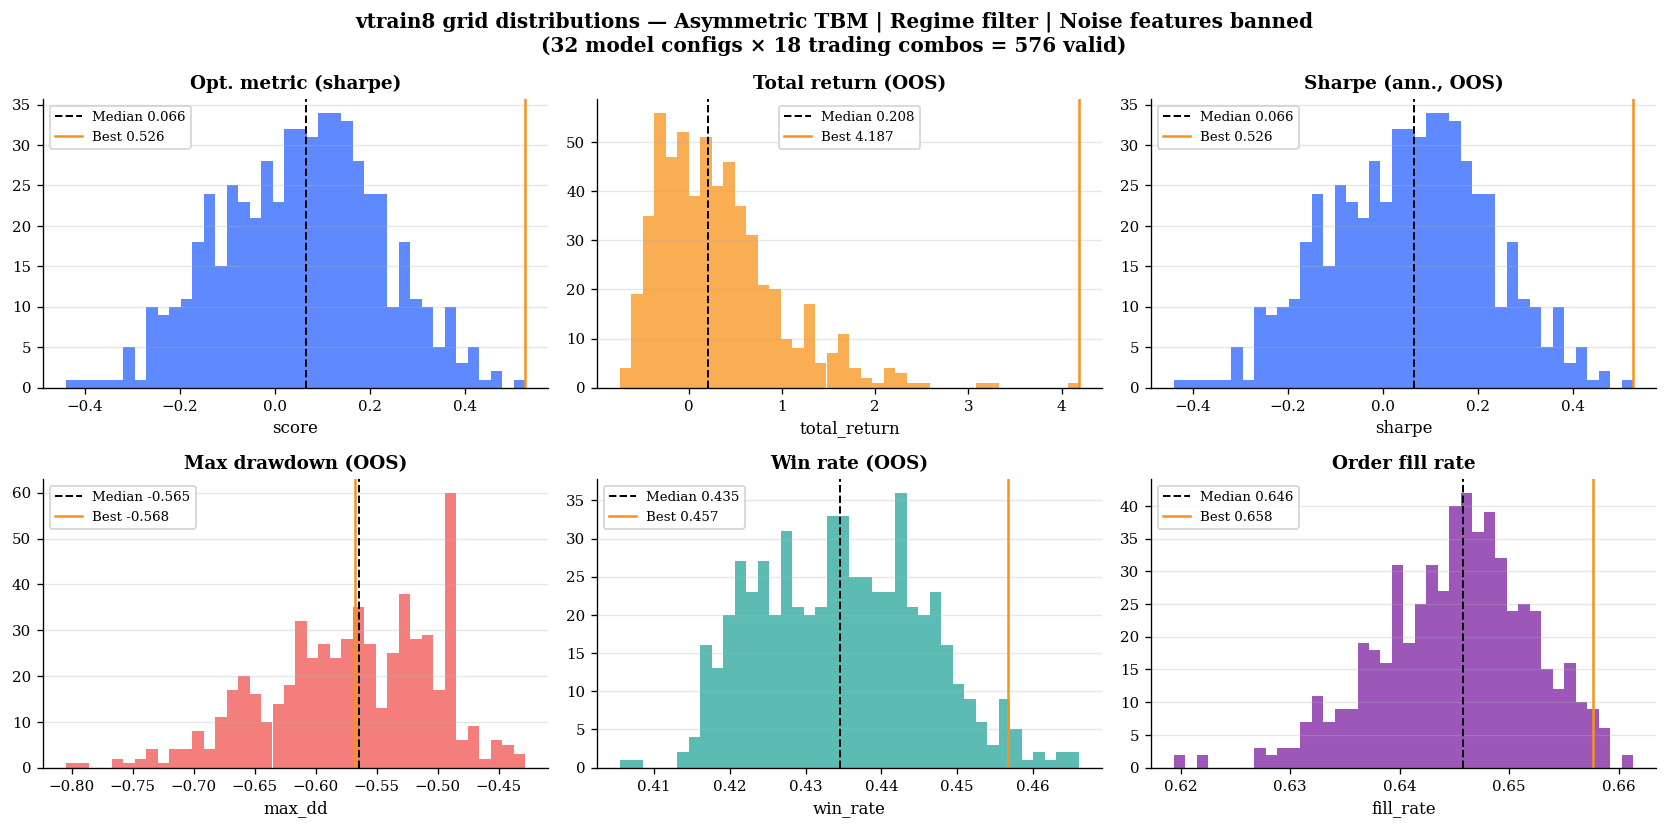

Per-model ranking (top 10):

 model_id  best_score  best_return  median_score  n_valid  auc_long  auc_short
       10    0.525831     4.187095      0.107563       18  0.533838   0.528222
       18    0.472063     3.248288      0.118365       18  0.534456   0.525662
        7    0.462066     2.490537      0.163963       18  0.527757   0.524148
       11    0.448185     3.105103      0.225466       18  0.533905   0.528933
        8    0.424432     2.160598      0.044651       18  0.536000   0.533101
        5    0.405918     1.907133      0.207831       18  0.532033   0.528460
        6    0.388731     2.131780      0.209306       18  0.530980   0.528110
        9    0.379177     2.272468      0.126477       18  0.531079   0.528268
        1    0.377441     2.146827      0.044398       18  0.531129   0.525386
       13    0.352208     1.585763      0.057400       18  0.527969   0.523824


In [9]:
# Distribution plots across all valid configs
if not results_df.empty:
    plot_cols = [
        ('score',          f'Opt. metric ({OPTIMISE_METRIC})',   BLUE),
        ('total_return',   'Total return (OOS)',                 ACCENT),
        ('sharpe',         'Sharpe (ann., OOS)',                 BLUE),
        ('max_dd',         'Max drawdown (OOS)',                 RED),
        ('win_rate',       'Win rate (OOS)',                     GREEN),
        ('fill_rate',      'Order fill rate',                    PURPLE),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, (col, title, color) in zip(axes.flat, plot_cols):
        data = results_df[col]
        ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='none')
        ax.axvline(data.median(), color='black', lw=1.2, ls='--',
                   label=f'Median {data.median():.3f}')
        ax.axvline(results_df[col].iloc[0], color=ACCENT, lw=1.5,
                   label=f'Best {results_df[col].iloc[0]:.3f}')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel(col); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    fig.suptitle(
        f'vtrain8 grid distributions — Asymmetric TBM | Regime filter | Noise features banned\n'
        f'({len(model_combos)} model configs × {len(valid_trading)} trading combos = {len(results_df):,} valid)',
        fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'grid_distributions_vtrain8.png'); plt.show()

    # Per-model leaderboard
    pm = (results_df.groupby('model_id')
          .agg(best_score=('score', 'max'), best_return=('total_return', 'max'),
               median_score=('score', 'median'), n_valid=('score', 'count'))
          .sort_values('best_score', ascending=False).reset_index())
    pm['auc_long']  = pm['model_id'].map({k: v['auc_long']  for k, v in oos_prob_cache.items()})
    pm['auc_short'] = pm['model_id'].map({k: v['auc_short'] for k, v in oos_prob_cache.items()})
    print('Per-model ranking (top 10):\n')
    print(pm.head(10).to_string(index=False))

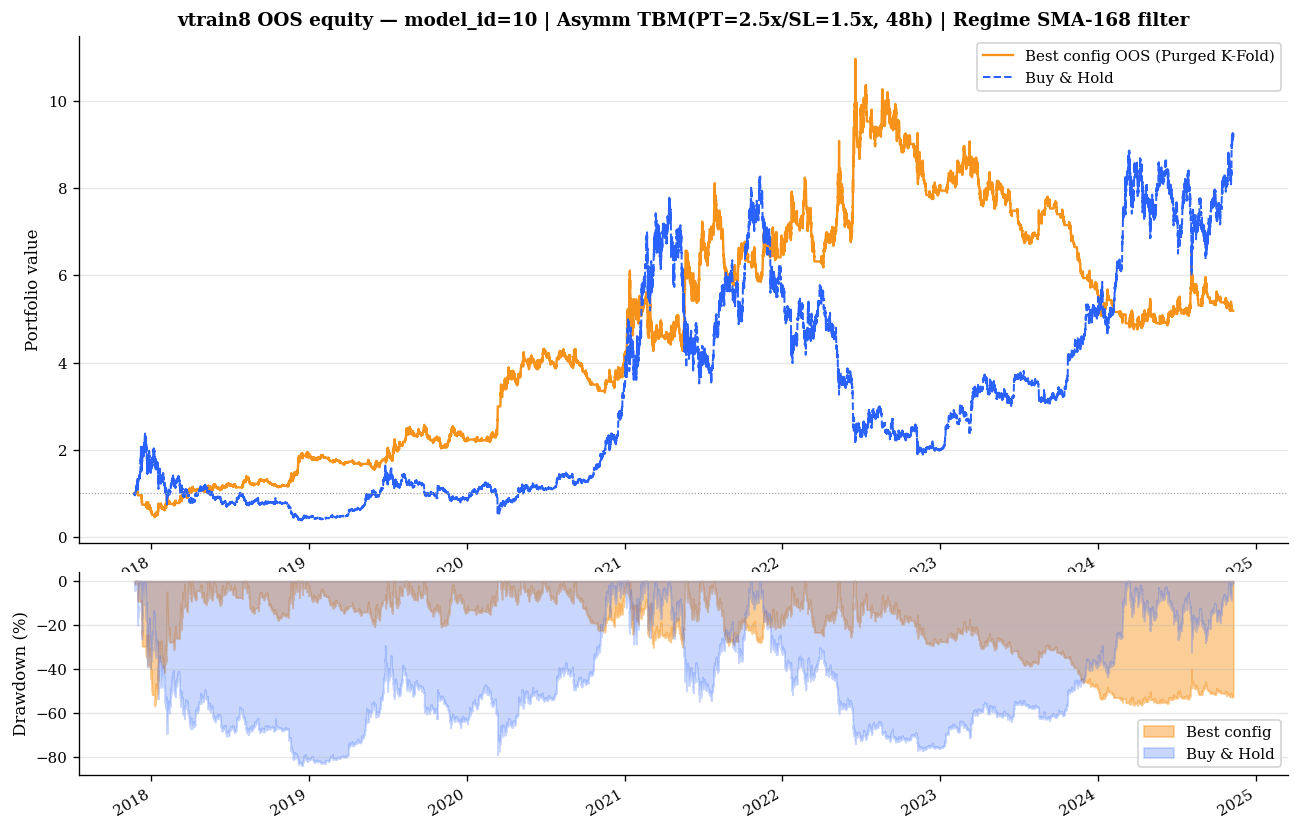

OOS K-Fold | Sharpe=0.526  Return=+418.71%  MaxDD=-56.82%  Trades=2330  Fill=65.8%  WR=45.7%
Long=462  Short=1868  TP=750  SL=1102  Conf=432
Regime filter blocked: 425 longs, 22451 shorts


In [10]:
# OOS equity curve for best config
cache = oos_prob_cache[best_mid]
eq_oos, tdf_oos = run_backtest_v8(
    cache['p_up'], cache['p_dn'],
    cache['c'], cache['h'], cache['l'], cache['a'], cache['s168'],
    best_params,
)
oos_idx = cache['oos_idx']
bh_oos  = cache['c'] / cache['c'][0]

min_len = min(len(oos_idx), len(eq_oos), len(bh_oos))
oos_idx = oos_idx[:min_len]; eq_oos = eq_oos[:min_len]; bh_oos = bh_oos[:min_len]

fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                          gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})
ax = axes[0]
ax.plot(oos_idx, eq_oos, color=ACCENT, lw=1.4, label='Best config OOS (Purged K-Fold)')
ax.plot(oos_idx, bh_oos, color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value'); ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_title(
    f'vtrain8 OOS equity — model_id={best_mid} | '
    f'Asymm TBM(PT={TBM_PT_MULT}x/SL={TBM_SL_MULT}x, {TBM_HORIZON}h) | '
    f'Regime SMA-{REGIME_SMA_PERIOD} filter',
    fontweight='bold')

ax = axes[1]
pk_s = np.maximum.accumulate(eq_oos); pk_b = np.maximum.accumulate(bh_oos)
ax.fill_between(oos_idx, (eq_oos - pk_s) / (pk_s + 1e-12) * 100, 0,
                color=ACCENT, alpha=0.45, label='Best config')
ax.fill_between(oos_idx, (bh_oos - pk_b) / (pk_b + 1e-12) * 100, 0,
                color=BLUE, alpha=0.25, label='Buy & Hold')
ax.set_ylabel('Drawdown (%)'); ax.legend(); ax.grid(axis='y', alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'oos_best_equity_vtrain8.png'); plt.show()

ret_oos = np.log(np.maximum(eq_oos[1:], 1e-12) / np.maximum(eq_oos[:-1], 1e-12))
pk_oos  = np.maximum.accumulate(eq_oos)
print(f'OOS K-Fold | '
      f'Sharpe={ret_oos.mean()/(ret_oos.std(ddof=1)+1e-12)*np.sqrt(24*365):.3f}  '
      f'Return={eq_oos[-1]-1:+.2%}  '
      f'MaxDD={((eq_oos-pk_oos)/(pk_oos+1e-12)).min():.2%}  '
      f'Trades={len(tdf_oos)}  '
      f'Fill={tdf_oos.attrs["n_fills"]/max(tdf_oos.attrs["n_signals"],1):.1%}  '
      f'WR={(tdf_oos["pnl_pct"]>0).mean():.1%}')
print(f'Long={int((tdf_oos["direction"]=="long").sum())}  '
      f'Short={int((tdf_oos["direction"]=="short").sum())}  '
      f'TP={int((tdf_oos["reason"]=="tp").sum())}  '
      f'SL={int((tdf_oos["reason"]=="sl").sum())}  '
      f'Conf={int((tdf_oos["reason"]=="conf").sum())}')
print(f'Regime filter blocked: {tdf_oos.attrs["n_longs_muted"]} longs, {tdf_oos.attrs["n_shorts_muted"]} shorts')

In [11]:
# Walk-Forward Optimization on test set
# Expanding window, monthly steps, same best model config

all_df = pd.concat([trainval_df, test_df]).sort_index()
n_tv   = len(trainval_df); n_test = len(test_df)

fi_best     = oos_prob_cache[best_mid]['fi']
X_all       = np.concatenate([X_tv, X_test], axis=0)[:, fi_best]
y_all       = np.concatenate([y_tv, y_test])

lgb_params_best = {
    **BASE_LGB_PARAMS,
    'num_leaves':        best_cfg['num_leaves'],
    'min_child_samples': best_cfg['min_child_samples'],
    'learning_rate':     best_cfg['learning_rate'],
}

wfo_probs   = np.full((n_test, 3), np.nan)
wfo_n_trees = []; step = 0
t0_wfo = time.perf_counter(); t = 0

while t < n_test:
    step_end    = min(t + WFO_STEP_H, n_test)
    n_wfo_train = n_tv + t
    X_wfo = X_all[:n_wfo_train]; y_wfo = y_all[:n_wfo_train]
    n_int   = min(WFO_INTERNAL_VAL_H, int(0.10 * n_wfo_train))
    X_vl_w  = X_wfo[-n_int:]; y_vl_w = y_wfo[-n_int:]
    X_tr_w  = X_wfo[:-n_int]; y_tr_w = y_wfo[:-n_int]

    ds_tr_w = lgb.Dataset(X_tr_w, label=y_tr_w)
    ds_vl_w = lgb.Dataset(X_vl_w, label=y_vl_w, reference=ds_tr_w)
    wfo_model = lgb.train(
        lgb_params_best, ds_tr_w,
        valid_sets=[ds_tr_w, ds_vl_w], valid_names=['train', 'val'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=WFO_PATIENCE, verbose=False),
            lgb.log_evaluation(period=0),
        ],
    )
    wfo_probs[t:step_end] = wfo_model.predict(X_all[n_tv + t: n_tv + step_end])
    wfo_n_trees.append(wfo_model.best_iteration)
    step += 1
    print(f'Step {step:>2}  train={n_wfo_train:,}  int_val={n_int:,}  '
          f'best_iter={wfo_model.best_iteration:>4}  {step_end/n_test*100:.0f}%')
    del wfo_model; t = step_end

wfo_p_up = wfo_probs[:, 1]; wfo_p_dn = wfo_probs[:, 0]
print(f'WFO done — {step} steps  {time.perf_counter()-t0_wfo:.1f}s  '
      f'mean_trees={np.mean(wfo_n_trees):.0f}')
print(f'P_up  range: [{wfo_p_up.min():.3f}, {wfo_p_up.max():.3f}]  mean={wfo_p_up.mean():.3f}')
print(f'P_down range: [{wfo_p_dn.min():.3f}, {wfo_p_dn.max():.3f}]  mean={wfo_p_dn.mean():.3f}')

Step  1  train=60,951  int_val=2,500  best_iter= 159  5%
Step  2  train=61,671  int_val=2,500  best_iter=  92  11%
Step  3  train=62,391  int_val=2,500  best_iter=  92  16%
Step  4  train=63,111  int_val=2,500  best_iter= 120  22%
Step  5  train=63,831  int_val=2,500  best_iter= 144  27%
Step  6  train=64,551  int_val=2,500  best_iter= 150  33%
Step  7  train=65,271  int_val=2,500  best_iter=  39  38%
Step  8  train=65,991  int_val=2,500  best_iter=  19  44%
Step  9  train=66,711  int_val=2,500  best_iter=  54  49%
Step 10  train=67,431  int_val=2,500  best_iter= 306  55%
Step 11  train=68,151  int_val=2,500  best_iter= 263  60%
Step 12  train=68,871  int_val=2,500  best_iter=  74  65%
Step 13  train=69,591  int_val=2,500  best_iter= 171  71%
Step 14  train=70,311  int_val=2,500  best_iter= 157  76%
Step 15  train=71,031  int_val=2,500  best_iter= 172  82%
Step 16  train=71,751  int_val=2,500  best_iter= 227  87%
Step 17  train=72,471  int_val=2,500  best_iter= 208  93%
Step 18  train=

In [12]:
bh_test = test_close / test_close[0]

# vtrain8 WFO
eq_wfo8, tdf_wfo8 = run_backtest_v8(
    wfo_p_up, wfo_p_dn, test_close, test_high, test_low, test_atr, test_sma168,
    best_params)

# vtrain8 static (single full-trainval retrain)
X_tv_best = X_tv[:, fi_best]; X_te_best = X_test[:, fi_best]
n_int_st  = min(WFO_INTERNAL_VAL_H, int(0.10 * len(X_tv_best)))
ds_tr_st  = lgb.Dataset(X_tv_best[:-n_int_st], label=y_tv[:-n_int_st])
ds_vl_st  = lgb.Dataset(X_tv_best[-n_int_st:],  label=y_tv[-n_int_st:], reference=ds_tr_st)
static_model = lgb.train(
    lgb_params_best, ds_tr_st,
    valid_sets=[ds_tr_st, ds_vl_st], valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(stopping_rounds=WFO_PATIENCE, verbose=False),
               lgb.log_evaluation(period=0)],
)
static_probs = static_model.predict(X_te_best)
eq_static8, tdf_static8 = run_backtest_v8(
    static_probs[:, 1], static_probs[:, 0],
    test_close, test_high, test_low, test_atr, test_sma168,
    best_params)
print(f'Static model trees: {static_model.best_iteration}')


def quick_metrics(eq, tdf, label):
    ret = np.log(np.maximum(eq[1:], 1e-12) / np.maximum(eq[:-1], 1e-12))
    pk  = np.maximum.accumulate(eq)
    sh  = float(ret.mean() / (ret.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))
    mdd = float(((eq - pk) / (pk + 1e-12)).min())
    an  = float((eq[-1] ** (24 * 365 / max(len(eq), 1))) - 1)
    wr  = float((tdf['pnl_pct'] > 0).mean()) if not tdf.empty else float('nan')
    fr  = (tdf.attrs.get('n_fills', 0) / max(tdf.attrs.get('n_signals', 1), 1)
           if hasattr(tdf, 'attrs') else float('nan'))
    pf  = 0.0
    if not tdf.empty:
        g = tdf[tdf['pnl_pct'] > 0]['pnl_pct'].sum()
        l = tdf[tdf['pnl_pct'] < 0]['pnl_pct'].abs().sum()
        pf = g / (l + 1e-6)
    long_ct  = int((tdf['direction'] == 'long').sum())  if not tdf.empty else 0
    short_ct = int((tdf['direction'] == 'short').sum()) if not tdf.empty else 0
    return {
        'Strategy':       label,
        'Total Return':   f'{eq[-1]-1:+.2%}',
        'Ann. Return':    f'{an:+.2%}',
        'Sharpe (ann.)':  f'{sh:.3f}',
        'Max DD':         f'{mdd:.2%}',
        'Calmar':         f'{an/(abs(mdd)+1e-6):.3f}',
        'Win Rate':       f'{wr:.1%}' if not np.isnan(wr) else 'N/A',
        'Profit Factor':  f'{pf:.3f}',
        'Trades':         str(len(tdf)),
        'Long / Short':   f'{long_ct} / {short_ct}',
        'Fill Rate':      f'{fr:.1%}' if not np.isnan(fr) else 'N/A',
    }


rows = [
    quick_metrics(eq_wfo8,    tdf_wfo8,    'vtrain8 WFO    (Regime filter, Asymm TBM)'),
    quick_metrics(eq_static8, tdf_static8, 'vtrain8 Static (Regime filter, Asymm TBM)'),
    quick_metrics(bh_test,    pd.DataFrame(), 'Buy & Hold'),
]
summary = pd.DataFrame(rows).set_index('Strategy')
print('\n' + '='*100)
print('  FINAL TEST-SET SUMMARY — vtrain8')
print('='*100)
print(summary.to_string())
print('='*100)

# Regime filter effectiveness
print(f'\nRegime filter impact (WFO test):')
print(f'  Long signals muted (bear regime): {tdf_wfo8.attrs.get("n_longs_muted", 0)}')
print(f'  Short signals muted (bull regime): {tdf_wfo8.attrs.get("n_shorts_muted", 0)}')
print(f'  Trades executed: {len(tdf_wfo8)} ({int((tdf_wfo8["direction"]=="long").sum())} long, '
      f'{int((tdf_wfo8["direction"]=="short").sum())} short)')

Static model trees: 159

  FINAL TEST-SET SUMMARY — vtrain8
                                          Total Return Ann. Return Sharpe (ann.)   Max DD  Calmar Win Rate Profit Factor Trades Long / Short Fill Rate
Strategy                                                                                                                                              
vtrain8 WFO    (Regime filter, Asymm TBM)      -42.90%     -31.05%        -1.352  -47.76%  -0.650    39.7%         0.874    413     12 / 401     58.8%
vtrain8 Static (Regime filter, Asymm TBM)      -40.72%     -29.32%        -1.264  -45.77%  -0.641    39.0%         0.883    405      3 / 402     57.8%
Buy & Hold                                      +3.75%      +2.47%         0.053  -50.08%   0.049      N/A         0.000      0        0 / 0      0.0%

Regime filter impact (WFO test):
  Long signals muted (bear regime): 0
  Short signals muted (bull regime): 5600
  Trades executed: 413 (12 long, 401 short)


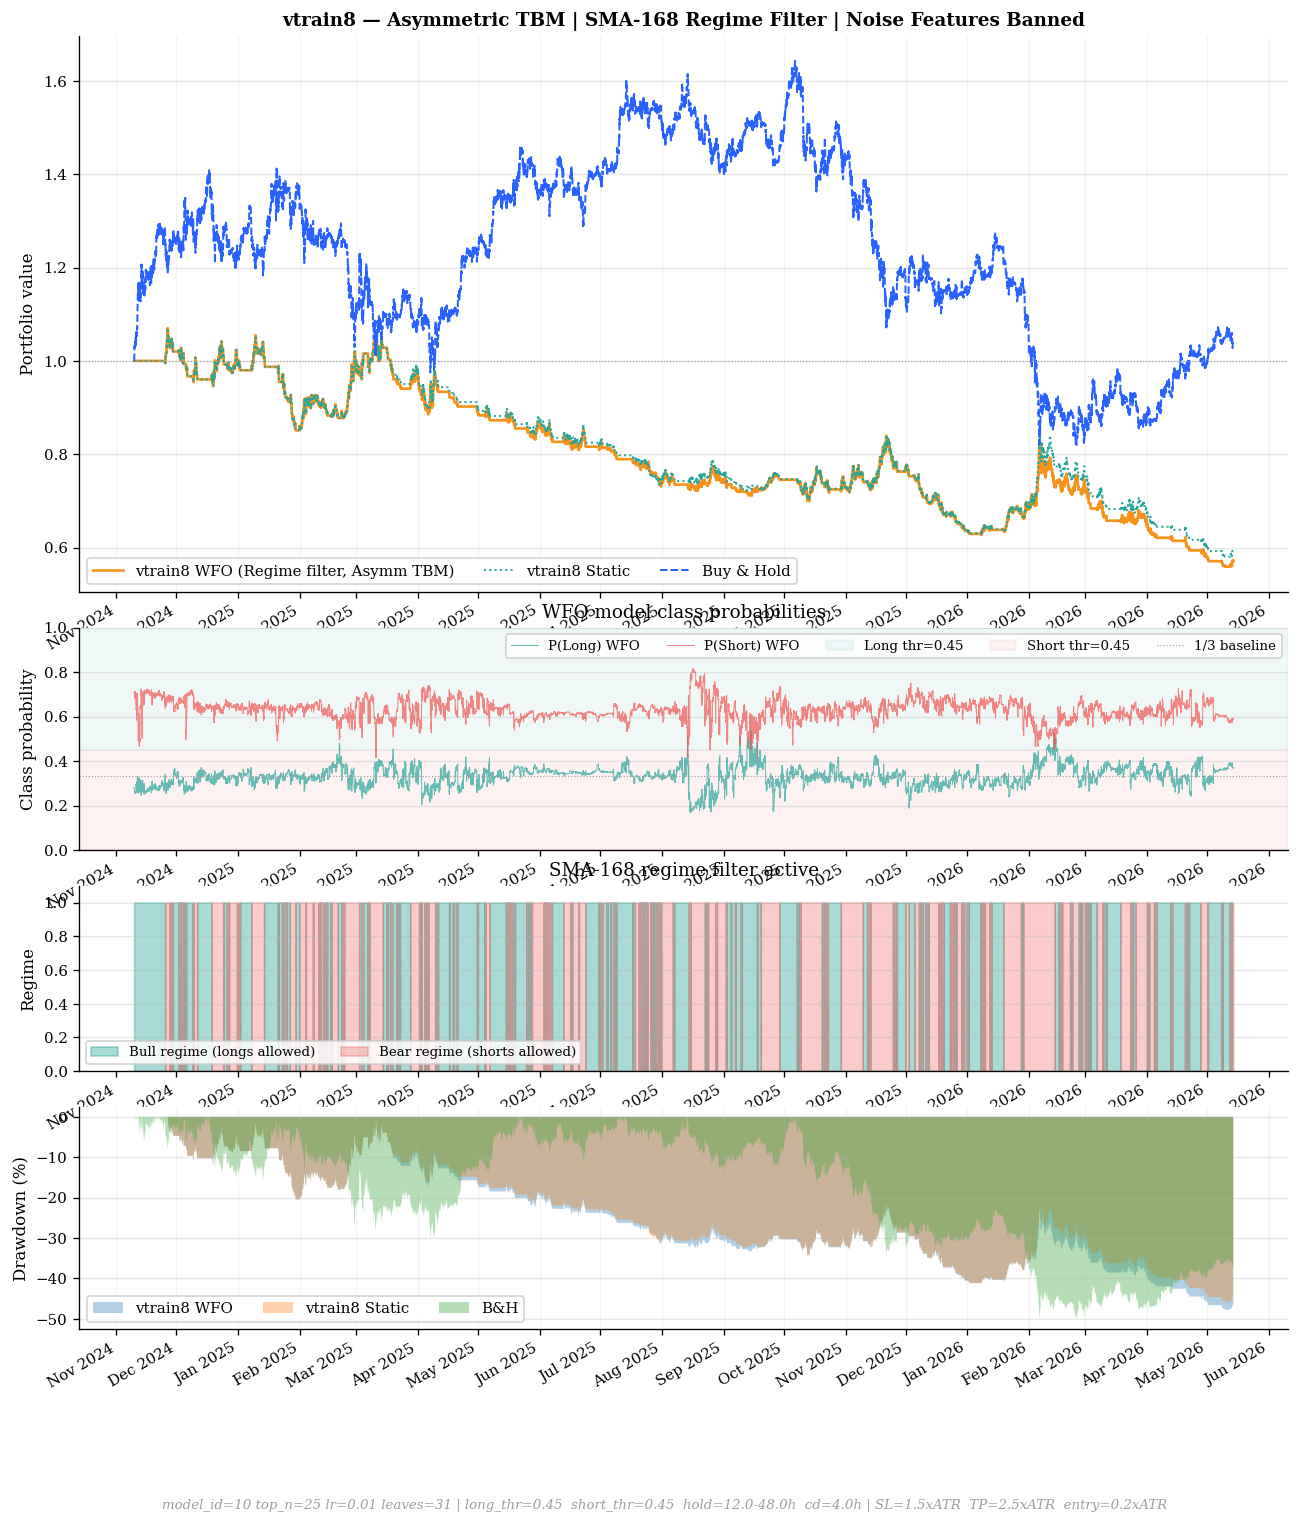

In [13]:
# Final visualization: equity, probabilities, regime, drawdown
fig, axes = plt.subplots(4, 1, figsize=(13, 14),
                          gridspec_kw={'height_ratios': [3, 1.2, 1.0, 1.2], 'hspace': 0.12})

# Panel 1: Equity curves
ax = axes[0]
ax.plot(test_index, eq_wfo8,    color=ACCENT, lw=1.6,
        label='vtrain8 WFO (Regime filter, Asymm TBM)')
ax.plot(test_index, eq_static8, color=GREEN,  lw=1.2, ls=':',  label='vtrain8 Static')
ax.plot(test_index, bh_test,    color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value')
ax.set_title('vtrain8 — Asymmetric TBM | SMA-168 Regime Filter | Noise Features Banned',
             fontweight='bold')
ax.legend(ncol=3); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

# Panel 2: Model probabilities
ax = axes[1]
ax.plot(test_index, wfo_p_up, color=GREEN, lw=0.6, alpha=0.7, label='P(Long) WFO')
ax.plot(test_index, wfo_p_dn, color=RED,   lw=0.6, alpha=0.7, label='P(Short) WFO')
ax.axhspan(best_params['long_threshold'],  1.0, alpha=0.07, color=GREEN,
           label=f'Long thr={best_params["long_threshold"]}')
ax.axhspan(0.0, best_params['short_threshold'], alpha=0.07, color=RED,
           label=f'Short thr={best_params["short_threshold"]}')
ax.axhline(1/3, color=GREY, ls=':', lw=0.7, label='1/3 baseline')
ax.set_ylim(0, 1); ax.set_ylabel('Class probability')
ax.set_title('WFO model class probabilities')
ax.legend(ncol=5, fontsize=8); ax.grid(axis='y', alpha=0.3)

# Panel 3: Regime (SMA-168) indicator
ax = axes[2]
regime_bull = test_close > test_sma168
ax.fill_between(test_index, regime_bull.astype(float), 0,
                color=GREEN, alpha=0.4, label='Bull regime (longs allowed)')
ax.fill_between(test_index, (~regime_bull).astype(float), 0,
                color=RED, alpha=0.3, label='Bear regime (shorts allowed)')
ax.set_ylim(0, 1.1); ax.set_ylabel('Regime')
ax.set_title(f'SMA-{REGIME_SMA_PERIOD} regime filter active')
ax.legend(ncol=2, fontsize=8); ax.grid(axis='y', alpha=0.3)

# Panel 4: Drawdown
ax = axes[3]
for eq, idx, color, lbl in [
    (eq_wfo8,    test_index, ACCENT, 'vtrain8 WFO'),
    (eq_static8, test_index, GREEN,  'vtrain8 Static'),
    (bh_test,    test_index, BLUE,   'B&H'),
]:
    pk = np.maximum.accumulate(eq)
    ax.fill_between(idx, (eq - pk) / (pk + 1e-12) * 100, 0, alpha=0.35, label=lbl)
ax.set_ylabel('Drawdown (%)'); ax.legend(ncol=3)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.003,
    f'model_id={best_mid} top_n={best_cfg["top_n_features"]} lr={best_cfg["learning_rate"]} '
    f'leaves={best_cfg["num_leaves"]} | '
    f'long_thr={best_params["long_threshold"]}  short_thr={best_params["short_threshold"]}  '
    f'hold={best_params["min_hold"]}-{best_params["max_hold"]}h  cd={best_params["cooldown"]}h | '
    f'SL={SL_ATR_MULT}xATR  TP={TP_ATR_MULT}xATR  entry={ENTRY_ATR_MULT}xATR',
    ha='center', fontsize=8, color=GREY, style='italic')
fig.savefig(FIGURES_DIR / 'wfo_equity_vtrain8.png'); plt.show()

Selected features for best model (top 25):
OK: No banned noise features in selected set

Top 20 features by gain importance:
                feature   importance
       regime_composite 72553.659460
        atr_14_pct_rank 66688.820769
      halving_cycle_cos 38345.347973
              skew_168h 34713.155227
            gk_vol_168h 34241.987196
              kurt_168h 33950.176624
       close_vs_sma_720 33634.820197
       dist_round_10000 33243.855422
supertrend_flip_recency 30621.916160
      close_vs_sma_2160 30190.156800
    candles_since_cross 29407.476913
      close_vs_sma_4320 28699.847939
               kurt_72h 28203.209082
       close_vs_sma_336 27044.188999
                sma_200 26835.285691
      halving_cycle_sin 25237.591869
         vol_of_vol_72h 24129.130993
               skew_72h 23290.295599
     supertrend_dist_15 22907.664194
          var_ratio_24h 22818.257891


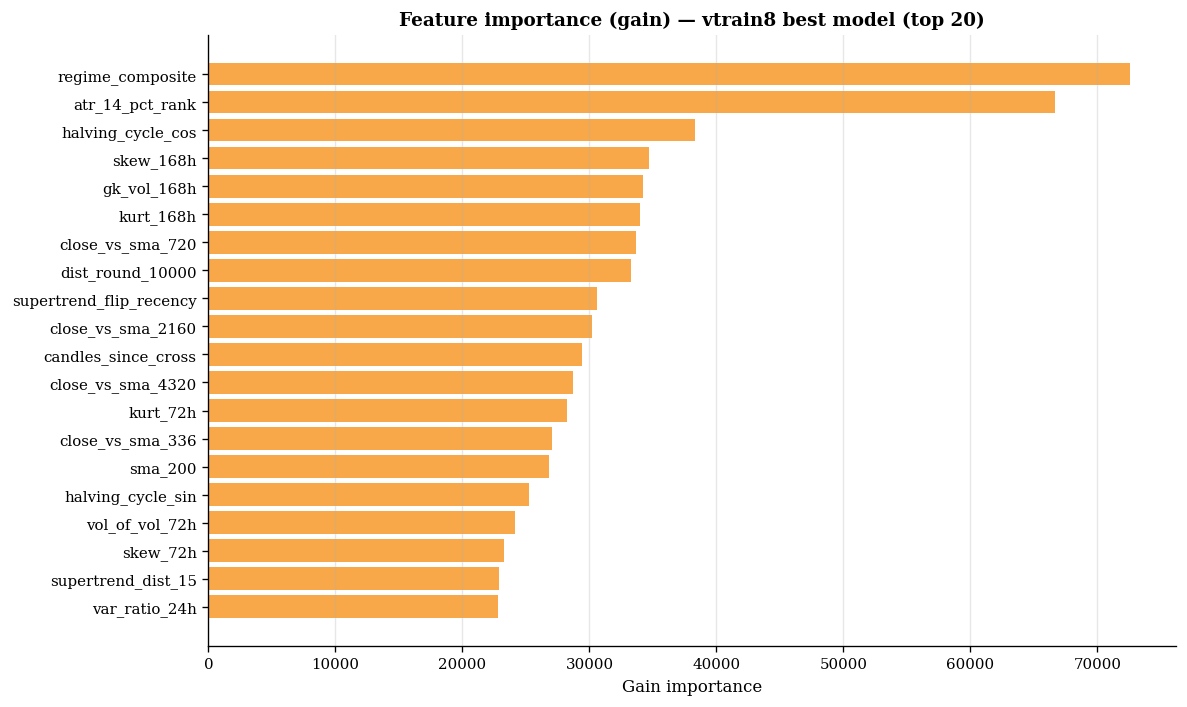

In [14]:
# Feature importance analysis — confirm noise features are absent, structural features dominate
top_feats = oos_prob_cache[best_mid]['sel_feats']
print(f'Selected features for best model (top {len(top_feats)}):')

# Train final static model for importance extraction
X_tv_imp = X_tv[:, fi_best]
n_imp    = min(2000, int(0.10 * len(X_tv_imp)))
ds_imp   = lgb.Dataset(X_tv_imp[:-n_imp], label=y_tv[:-n_imp])
ds_vl_i  = lgb.Dataset(X_tv_imp[-n_imp:],  label=y_tv[-n_imp:], reference=ds_imp)
imp_model = lgb.train(
    lgb_params_best, ds_imp,
    valid_sets=[ds_imp, ds_vl_i], valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False),
               lgb.log_evaluation(period=0)],
)

importances = imp_model.feature_importance(importance_type='gain')
feat_names  = [top_feats[i] for i in range(len(top_feats))]
imp_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
imp_df = imp_df.sort_values('importance', ascending=False).reset_index(drop=True)

# Flag any banned features (should be absent)
banned_present = [f for f in imp_df['feature'] if f in BANNED_FEATURES]
if banned_present:
    print(f'WARNING: Banned features found in selection: {banned_present}')
else:
    print('OK: No banned noise features in selected set')

print('\nTop 20 features by gain importance:')
print(imp_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
n_show = min(20, len(imp_df))
ax.barh(imp_df['feature'][:n_show][::-1], imp_df['importance'][:n_show][::-1],
        color=ACCENT, alpha=0.8)
ax.set_title(f'Feature importance (gain) — vtrain8 best model (top {n_show})', fontweight='bold')
ax.set_xlabel('Gain importance'); ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'feature_importance_vtrain8.png'); plt.show()

In [15]:
# Save results and best params
results_path = MODELS_DIR / 'lgbm_grid_results_vtrain8.csv'
results_df.to_csv(results_path, index=False)
print(f'Saved {len(results_df):,} grid results -> {results_path}')

ret_wfo  = np.log(np.maximum(eq_wfo8[1:],  1e-12) / np.maximum(eq_wfo8[:-1],  1e-12))
ret_oos2 = np.log(np.maximum(eq_oos[1:],   1e-12) / np.maximum(eq_oos[:-1],   1e-12))
pk_wfo   = np.maximum.accumulate(eq_wfo8)
pk_oos2  = np.maximum.accumulate(eq_oos)

output = {
    'version': 'vtrain8',
    'changes_vs_vtrain7': [
        f'Banned noise features: {sorted(BANNED_FEATURES)}',
        f'Asymmetric TBM: PT={TBM_PT_MULT}xATR (was 2.0x) / SL={TBM_SL_MULT}xATR (was 2.0x)',
        f'Extended horizon: {TBM_HORIZON}h (was 24h)',
        f'SMA-{REGIME_SMA_PERIOD} regime filter: mute shorts in bull, mute longs in bear',
        f'Fixed SL/TP in backtester (not grid-searched)',
        f'Constrained trading grid: {len(valid_trading)} combos (was 6912)',
        f'Total evaluations: {len(model_combos)*len(valid_trading)} (was 331k)',
    ],
    'execution': {
        'maker_fee':         MAKER_FEE,
        'spot_taker_fee':    SPOT_TAKER_FEE,
        'futures_taker_fee': FUTURES_TAKER_FEE,
        'buffer':            BUFFER,
        'spot_funding_h':    SPOT_FUNDING_H,
        'short_funding_h':   SHORT_FUNDING_H,
        'entry_atr_mult':    ENTRY_ATR_MULT,
        'sl_atr_mult':       SL_ATR_MULT,
        'tp_atr_mult':       TP_ATR_MULT,
        'min_sl':            MIN_SL,
    },
    'tbm': {
        'pt_mult': TBM_PT_MULT, 'sl_mult': TBM_SL_MULT, 'horizon': TBM_HORIZON,
    },
    'regime_filter': {'sma_period': REGIME_SMA_PERIOD},
    'best_model_id':       best_mid,
    'best_model_config':   best_cfg,
    'best_trading_params': best_params,
    'oos_auc': {
        'long':  round(oos_prob_cache[best_mid]['auc_long'],  4),
        'short': round(oos_prob_cache[best_mid]['auc_short'], 4),
    },
    'oos_kfold': {
        'sharpe':       round(float(ret_oos2.mean() / (ret_oos2.std(ddof=1) + 1e-12) * np.sqrt(24*365)), 4),
        'total_return': round(float(eq_oos[-1] - 1), 4),
        'max_dd':       round(float(((eq_oos - pk_oos2) / (pk_oos2 + 1e-12)).min()), 4),
        'n_trades':     int(len(tdf_oos)),
        'fill_rate':    round(tdf_oos.attrs.get('n_fills', 0) / max(tdf_oos.attrs.get('n_signals', 1), 1), 4),
        'n_longs_muted':  tdf_oos.attrs.get('n_longs_muted', 0),
        'n_shorts_muted': tdf_oos.attrs.get('n_shorts_muted', 0),
    },
    'test_wfo': {
        'sharpe':         round(float(ret_wfo.mean() / (ret_wfo.std(ddof=1) + 1e-12) * np.sqrt(24*365)), 4),
        'total_return':   round(float(eq_wfo8[-1] - 1), 4),
        'max_dd':         round(float(((eq_wfo8 - pk_wfo) / (pk_wfo + 1e-12)).min()), 4),
        'n_trades':       int(len(tdf_wfo8)),
        'fill_rate':      round(tdf_wfo8.attrs.get('n_fills', 0) / max(tdf_wfo8.attrs.get('n_signals', 1), 1), 4),
        'n_long':         int((tdf_wfo8['direction'] == 'long').sum()),
        'n_short':        int((tdf_wfo8['direction'] == 'short').sum()),
        'n_longs_muted':  tdf_wfo8.attrs.get('n_longs_muted', 0),
        'n_shorts_muted': tdf_wfo8.attrs.get('n_shorts_muted', 0),
    },
}

params_path = MODELS_DIR / 'lgbm_best_trading_params_vtrain8.json'
with open(params_path, 'w') as f:
    json.dump(output, f, indent=2)
print(f'Saved best params -> {params_path}')
print()
print(json.dumps(output, indent=2))

Saved 576 grid results -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/lgbm_grid_results_vtrain8.csv
Saved best params -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models/lgbm_best_trading_params_vtrain8.json

{
  "version": "vtrain8",
  "changes_vs_vtrain7": [
    "Banned noise features: ['close_vs_ema_7', 'log_ret_1h', 'log_ret_2h', 'ret_1h', 'ret_2h']",
    "Asymmetric TBM: PT=2.5xATR (was 2.0x) / SL=1.5xATR (was 2.0x)",
    "Extended horizon: 48h (was 24h)",
    "SMA-168 regime filter: mute shorts in bull, mute longs in bear",
    "Fixed SL/TP in backtester (not grid-searched)",
    "Constrained trading grid: 18 combos (was 6912)",
    "Total evaluations: 576 (was 331k)"
  ],
  "execution": {
    "maker_fee": 0.0,
    "spot_taker_fee": 0.0005,
    "futures_taker_fee": 0.0005,
    "buffer": 0.0005,
    "spot_funding_h": 0.0,
    "short_funding_h": 7.7e-06,
    "entry_atr_mult": 0.2,
    "sl_atr_mult": 1.5,
    "tp_atr